# Análisis de sentimientos: Word2Vec preentrenado + RNN

En esta versión se simplifica deliberadamente el proceso. Vamos a considerar el uso de Word2Vec y las redes neuronales secuenciales o recurrentes. En este caso si consideraremos el orden de las palabras en el tweet.

**Word2Vec no se entrena.** Se parte de un modelo Word2Vec ya entrenado y cada tweet se procesa así:

$$
\text{tweet}
\rightarrow \text{tokens}
\rightarrow \text{vectores Word2Vec}
\rightarrow \text{padding}
\rightarrow \text{RNN}
\rightarrow \text{capa densa}
\rightarrow \text{sentimiento}
$$

Para cada token:

- si existe en Word2Vec, se toma directamente su vector;
- si no existe, **se ignora**;
- no se crea `<UNK>`;
- los vectores Word2Vec permanecen fijos.

Por tanto, lo único que aprende este ejercicio es la **RNN y su capa densa final**.


In [ ]:
import re
import string
import unicodedata
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize

from gensim.models import KeyedVectors

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## 1. Carga de los tweets

Se utiliza el mismo `sentimientos.csv` del ejercicio anterior.


In [ ]:
df = pd.read_csv("sentimientos.csv")

print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))
display(df.head())

col_texto = df.columns[0]
col_polaridad = df.columns[1]

print(df[col_polaridad].value_counts(dropna=False))

Dimensiones: (7219, 3)
Columnas: ['content', 'polarity', 'agreement']


,content,polarity,agreement
0,"Salgo de #VeoTV , que día más largoooooo...",NONE,AGREEMENT
1,@PauladeLasHeras No te libraras de ayudar me/n...,NEU,DISAGREEMENT
2,@marodriguezb Gracias MAR,P,AGREEMENT
3,"Off pensando en el regalito Sinde, la que se v...",N+,AGREEMENT
4,Conozco a alguien q es adicto al drama! Ja ja ...,P+,AGREEMENT


polarity
P+      1652
NONE    1483
N       1335
P       1232
N+       847
NEU      670
Name: count, dtype: int64


## 2. Normalización sencilla

En este ejercicio **no hacemos stemming**, porque queremos buscar las palabras en un Word2Vec preentrenado. Si transformáramos `gustando` en una raíz artificial como `gust`, es posible que esa raíz no exista en el vocabulario de Word2Vec.

Conservamos además las negaciones y palabras cortas relevantes para sentimiento.


In [ ]:
  import nltk
  nltk.download('punkt_tab')

  def normalizar(texto):
    texto = unicodedata.normalize("NFC", str(texto).lower())
    texto = re.sub(r"[^a-záéíóúüñ\\s]", " ", texto)
    texto = re.sub(r"\\s+", " ", texto).strip()

    tokens = word_tokenize(texto, language="spanish")

    return [
        token for token in tokens
        if token not in string.punctuation
    ]

for frase in [
    "Sí me gusta mucho este producto",
    "No me gusta este producto",
    "Nunca volvería a comprarlo"
]:
    print(frase, "->", normalizar(frase))

Sí me gusta mucho este producto -> ['sí', 'me', 'gusta', 'mucho', 'este', 'producto']
No me gusta este producto -> ['no', 'me', 'gusta', 'este', 'producto']
Nunca volvería a comprarlo -> ['nunca', 'volvería', 'a', 'comprarlo']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 3. Carga de Word2Vec

Aquí se carga un archivo Word2Vec **preentrenado**. No se ejecuta `Word2Vec(...)`, ni `fit`, ni ningún entrenamiento de embeddings.

.


In [ ]:
import gensim.downloader as api
word_vectors = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


## 4. Convertir cada tweet directamente en una secuencia de vectores

Esta es la idea central.

Supongamos que un tweet normalizado contiene:

```text
["producto", "excelente", "entrega", "rapidísima"]
```

Para cada palabra buscamos:

```python
word_vectors["producto"]
word_vectors["excelente"]
...
```

Cada palabra encontrada produce un vector:

$$
\mathbf{x}_t \in \mathbb{R}^{d}
$$

Si una palabra **no existe** en Word2Vec, simplemente se descarta.

El tweet queda entonces representado como una matriz:

$$
X =
\begin{bmatrix}
\mathbf{x}_1\\
\mathbf{x}_2\\
\vdots\\
\mathbf{x}_T
\end{bmatrix}
\in\mathbb{R}^{T\times d}
$$

No necesitamos una capa `nn.Embedding`, porque los vectores ya vienen directamente de Word2Vec.


In [ ]:
def tweet_a_word2vec(texto):
    tokens = normalizar(texto)

    tokens_encontrados = [
        token for token in tokens
        if token in word_vectors
    ]

    if len(tokens_encontrados) == 0:
        return None, []

    vectores = np.stack([
        word_vectors[token]
        for token in tokens_encontrados
    ]).astype(np.float32)

    return vectores, tokens_encontrados


# Ejemplo
texto_ejemplo = str(df.iloc[0][col_texto])
vectores, tokens_validos = tweet_a_word2vec(texto_ejemplo)

print("Tweet:")
print(texto_ejemplo)
print("\nTokens encontrados en Word2Vec:")
print(tokens_validos)

if vectores is not None:
    print("\nForma de la representación:", vectores.shape)

Tweet:
Salgo de #VeoTV , que día más largoooooo...

Tokens encontrados en Word2Vec:
['de', 'que', 'día', 'más']

Forma de la representación: (4, 300)


## 5. Preparación del dataset

Las polaridades se agrupan nuevamente en tres clases.


In [ ]:
replace = {
    "n": 0,
    "n+": 0,
    "neu": 1,
    "p": 2,
    "p+": 2
}

nombres_clases = ["Negativo", "Neutral", "Positivo"]

secuencias = []
etiquetas = []
tokens_por_tweet = []

ignorados = 0

for _, fila in df.iterrows():
    texto = fila[col_texto]
    polaridad = str(fila[col_polaridad]).lower().strip()

    if pd.isna(texto) or polaridad not in replace:
        continue

    vectores, tokens_validos = tweet_a_word2vec(texto)

    # Si Word2Vec no reconoce ninguna palabra del tweet,
    # no podemos construir una secuencia para la RNN.
    if vectores is None:
        ignorados += 1
        continue

    secuencias.append(vectores)
    etiquetas.append(replace[polaridad])
    tokens_por_tweet.append(tokens_validos)

print("Tweets utilizables:", len(secuencias))
print("Tweets sin palabras reconocidas:", ignorados)

print("\nEjemplo:")
print("Tokens:", tokens_por_tweet[0])
print("Matriz:", secuencias[0].shape)
print("Clase:", nombres_clases[etiquetas[0]])

Tweets utilizables: 5723
Tweets sin palabras reconocidas: 13

Ejemplo:
Tokens: ['no', 'te', 'de', 'ayudar', 'me', 'nos', 'y', 'gracias']
Matriz: (8, 300)
Clase: Neutral


## 6. Padding

Cada tweet tiene un número diferente de palabras:

$$
X_1\in\mathbb{R}^{5\times d},\qquad
X_2\in\mathbb{R}^{12\times d},\qquad
X_3\in\mathbb{R}^{8\times d}
$$

Para formar un batch, `pad_sequence` completa las secuencias más cortas con **vectores de ceros**.

Si la secuencia más larga del batch tiene 12 palabras:

$$
X_{\text{batch}}\in
\mathbb{R}^{B\times12\times d}
$$

También guardamos la longitud real de cada tweet para que la RNN pueda ignorar posteriormente el padding.


Construimos la representación de los tweets por vectores organizados, incluyendo la información necesaria por la red RNN

In [ ]:
class TweetDataset(Dataset):
    def __init__(self, secuencias, etiquetas):
        self.X = [
            torch.tensor(x, dtype=torch.float32)
            for x in secuencias
        ]
        self.y = torch.tensor(etiquetas, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def collate_padding(batch):
    secuencias_batch, etiquetas_batch = zip(*batch)

    longitudes = torch.tensor(
        [len(x) for x in secuencias_batch],
        dtype=torch.long
    )

    X_padded = nn.utils.rnn.pad_sequence(
        secuencias_batch,
        batch_first=True,
        padding_value=0.0
    )

    y = torch.stack(etiquetas_batch)

    return X_padded, longitudes, y

In [ ]:
indices = np.arange(len(secuencias))

idx_train, idx_test = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=np.asarray(etiquetas)
)

train_ds = TweetDataset(
    [secuencias[i] for i in idx_train],
    [etiquetas[i] for i in idx_train]
)

test_ds = TweetDataset(
    [secuencias[i] for i in idx_test],
    [etiquetas[i] for i in idx_test]
)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_padding
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_padding
)

X_batch, longitudes, y_batch = next(iter(train_loader))

print("Forma del batch después del padding:")
print(X_batch.shape)
print("\nLongitudes reales de los primeros tweets:")
print(longitudes[:10])

print("\nInterpretación:")
print("Número de tweets:", X_batch.shape[0])
print("Longitud máxima del batch:", X_batch.shape[1])
print("Dimensión Word2Vec:", X_batch.shape[2])

Forma del batch después del padding:
torch.Size([64, 25, 300])

Longitudes reales de los primeros tweets:
tensor([16, 25, 18, 15,  7, 16, 19,  4, 12,  9])

Interpretación:
Número de tweets: 64
Longitud máxima del batch: 25
Dimensión Word2Vec: 300


## 7. RNN

Ahora la arquitectura es particularmente sencilla:

$$
(B,T,d)
\rightarrow
\text{RNN}
\rightarrow
\mathbf{h}_T
\rightarrow
\text{Linear}(H,3)
$$

No existe capa `Embedding`.

La entrada de la RNN son directamente los vectores Word2Vec.

`pack_padded_sequence` hace que la RNN utilice las longitudes reales y no procese como palabras los vectores de ceros añadidos durante el padding.

Es importante recordar que la red RNN no entrega la polaridad sino una representación $\mathbf{h}_T$ que codifica el tweet tendiendo en cuenta su orden.

In [ ]:
EMBED_DIM=300

#Esta es la implementación de la red RNN, puede observar que en estructura es casi lo mismo que la red LSTM
class SentimentRNN(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=64, num_classes=3):
        super().__init__()
        self.rnn = nn.RNN(
              input_size=embedding_dim,
              hidden_size=hidden_dim,
              batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, X, longitudes):
        packed = nn.utils.rnn.pack_padded_sequence(
            X,
            longitudes.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, h_n = self.rnn(packed)

        # Estado oculto final de cada tweet
        h_final = h_n[-1]

        # Salida densa: 3 logits
        logits = self.fc(h_final)

        return logits

#Esta es la implementación de la red LSTM
class SentimentLSTM(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=64, num_classes=3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, X, longitudes):

        packed = nn.utils.rnn.pack_padded_sequence(
            X,
            longitudes.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (h_n, c_n) = self.lstm(packed)

        # Último estado oculto de cada tweet
        h_final = h_n[-1]

        # Clasificación
        logits = self.fc(h_final)

        return logits

#model = SentimentRNN(embedding_dim=EMBED_DIM,hidden_dim=64,num_classes=3).to(device)
model = SentimentLSTM(embedding_dim=EMBED_DIM,hidden_dim=64,num_classes=3).to(device)

print(model)

SentimentLSTM(
  (lstm): LSTM(300, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


## 8. Entrenamiento

Ahora sí se aprende, pero solamente en:

- los parámetros internos de la RNN;
- la capa densa `Linear(64, 3)`.

Los vectores Word2Vec **no forman parte del modelo entrenable**.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

EPOCHS = 200
hist_loss = []

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0.0
    total = 0

    for X, longitudes, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(X, longitudes)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total += y.size(0)

    epoch_loss = total_loss / total
    hist_loss.append(epoch_loss)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} "
        f"- loss: {epoch_loss:.4f}"
    )

Epoch 01/200 - loss: 0.9821
Epoch 02/200 - loss: 0.9120
Epoch 03/200 - loss: 0.8747
Epoch 04/200 - loss: 0.8554
Epoch 05/200 - loss: 0.8454
Epoch 06/200 - loss: 0.8262
Epoch 07/200 - loss: 0.8179
Epoch 08/200 - loss: 0.8136
Epoch 09/200 - loss: 0.8002
Epoch 10/200 - loss: 0.7906
Epoch 11/200 - loss: 0.7782
Epoch 12/200 - loss: 0.7764
Epoch 13/200 - loss: 0.7661
Epoch 14/200 - loss: 0.7551
Epoch 15/200 - loss: 0.7461
Epoch 16/200 - loss: 0.7376
Epoch 17/200 - loss: 0.7353
Epoch 18/200 - loss: 0.7210
Epoch 19/200 - loss: 0.7139
Epoch 20/200 - loss: 0.7139
Epoch 21/200 - loss: 0.6915
Epoch 22/200 - loss: 0.6924
Epoch 23/200 - loss: 0.6698
Epoch 24/200 - loss: 0.6543
Epoch 25/200 - loss: 0.6385
Epoch 26/200 - loss: 0.6309
Epoch 27/200 - loss: 0.6127
Epoch 28/200 - loss: 0.6050
Epoch 29/200 - loss: 0.5860
Epoch 30/200 - loss: 0.5782
Epoch 31/200 - loss: 0.5621
Epoch 32/200 - loss: 0.5468
Epoch 33/200 - loss: 0.5265
Epoch 34/200 - loss: 0.5126
Epoch 35/200 - loss: 0.5188
Epoch 36/200 - loss:

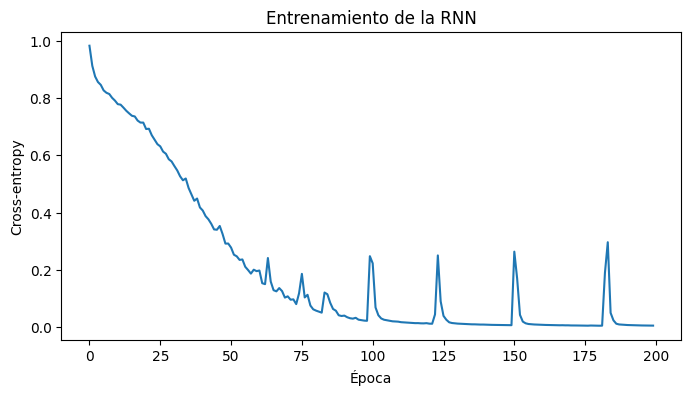

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_loss)
plt.xlabel("Época")
plt.ylabel("Cross-entropy")
plt.title("Entrenamiento de la RNN")
plt.show()

## 9. Evaluación


              precision    recall  f1-score   support

    Negativo     0.5273    0.5092    0.5181       436
     Neutral     0.1250    0.1119    0.1181       134
    Positivo     0.6424    0.6748    0.6582       575

    accuracy                         0.5459      1145
   macro avg     0.4316    0.4320    0.4315      1145
weighted avg     0.5380    0.5459    0.5416      1145



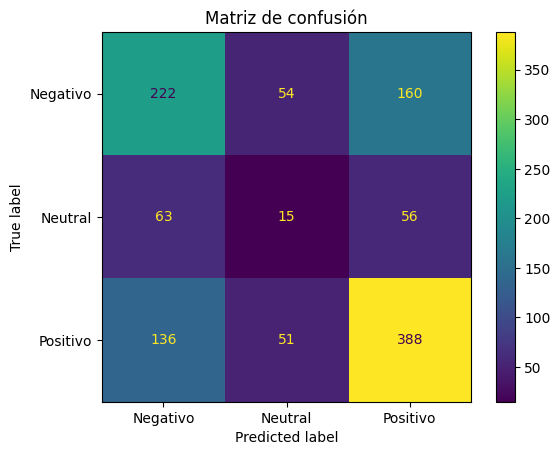

In [ ]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X, longitudes, y in test_loader:
        X = X.to(device)

        logits = model(X, longitudes)
        pred = logits.argmax(dim=1).cpu()

        y_true.extend(y.numpy().tolist())
        y_pred.extend(pred.numpy().tolist())

print(classification_report(
    y_true,
    y_pred,
    target_names=nombres_clases,
    digits=4
))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=nombres_clases
)
plt.title("Matriz de confusión")
plt.show()

## 10. Predicción de un tweet nuevo

La inferencia repite exactamente el mismo proceso:

\[
\text{texto}
\rightarrow
\text{tokens}
\rightarrow
\text{Word2Vec}
\rightarrow
\text{RNN}
\rightarrow
\text{Linear}
\rightarrow
\text{sentimiento}
\]


In [ ]:
def predecir(frase):
    vectores, tokens_validos = tweet_a_word2vec(frase)

    if vectores is None:
        print("Ninguna palabra de la frase aparece en Word2Vec.")
        return None

    X = torch.tensor(
        vectores,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    longitudes = torch.tensor(
        [X.shape[1]],
        dtype=torch.long
    )

    model.eval()

    with torch.no_grad():
        logits = model(X, longitudes)
        probabilidades = torch.softmax(logits, dim=1)[0].cpu().numpy()
        clase = int(np.argmax(probabilidades))

    print("Frase:", frase)
    print("Tokens utilizados:", tokens_validos)
    print("Forma de entrada a la RNN:", X.shape)
    print("Sentimiento:", nombres_clases[clase])
    print("Probabilidades:", {
        nombre: round(float(p), 4)
        for nombre, p in zip(nombres_clases, probabilidades)
    })

    return clase


predecir("No me gusta ver televisión, la programación es muy aburridora")
predecir("Estoy muy contento con el resultado")

Frase: No me gusta ver televisión, la programación es muy aburridora
Tokens utilizados: ['no', 'me', 'gusta', 'ver', 'televisión', 'la', 'es', 'muy']
Forma de entrada a la RNN: torch.Size([1, 8, 300])
Sentimiento: Positivo
Probabilidades: {'Negativo': 0.0, 'Neutral': 0.0001, 'Positivo': 0.9999}
Frase: Estoy muy contento con el resultado
Tokens utilizados: ['estoy', 'muy', 'con', 'el', 'resultado']
Forma de entrada a la RNN: torch.Size([1, 5, 300])
Sentimiento: Positivo
Probabilidades: {'Negativo': 0.0, 'Neutral': 0.0, 'Positivo': 1.0}


2

## Resumen

En esta versión Word2Vec funciona exclusivamente como un **diccionario externo de vectores**:

```text
"excelente" ──→ vector Word2Vec
"producto"  ──→ vector Word2Vec
"xyzabc"    ──→ no existe → se ignora
```

Por tanto, para un tweet con \(T\) palabras reconocidas obtenemos:

$$
X\in\mathbb{R}^{T\times d}
$$

El padding permite agrupar varias de estas matrices en un batch:

$$
X_{\text{batch}}\in\mathbb{R}^{B\times T_{\max}\times d}
$$

La RNN recibe directamente estos vectores, produce un estado oculto final \(h_T\), y una capa densa transforma ese estado en tres logits:

$$
h_T
\rightarrow
\text{Linear}
\rightarrow
[\text{negativo},\text{neutral},\text{positivo}]
$$

Así queda claramente separado qué parte **ya viene aprendida** (Word2Vec) y qué parte **entrenamos nosotros** (RNN + capa densa).
